# Satisfaction Drivers Analysis

# Directory architecture
```
project/
    /assets/*.png
    /impact/*_impact.csv
    /models/model_*.pkl, shap_*_explanation.pkl, *_shap_values.csv
    /shap_bin/shap_*.npy
```


# 0. PART 1 Imports and Load

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import datetime


In [2]:
# Load survey data
data = pd.read_csv('df_single_with_grps.csv')

# We drop some columns that are not useful or have too many levels
to_remove = ['age', 'age_grp', 'gender', 'educstat', 'comp_related_degree', 'city_ph', 'city_non_ph','region_ph', 'salary', 'country', 'industry', 'resp_id_rand', 'resp_id']
data = data[data['satisfaction'] != 999.0]

target = 'satisfaction'
X = data.drop(columns=[target] + to_remove)
y = data[target]

ordinal_maps = {
    'salary_broader': {
        '35k and less': 1,
        '35k+ to 75k':       2,
        '75k+ to 100k':      3,
        '100k and above':         4,
    },
    'how_long_in_salary': {
        'a. 3mos or less':    1,
        'b. >3 to 6mos':      2,
        'c. >6mos to 1yr':    3,
        'd. >1yr to 2yrs':    4,
        'e. >2 yrs to 5yrs':  5,
        'f. >5 yrs to 10yrs': 6,
        'g. >10yrs':          7,
    },
    'sizeteam': {
        '1 - Just me': 1,
        '2 to 3':      2,
        '4 to 5':      3,
        '6 to 10':     4,
        '11 to 30':    5,
        '30+':         6,
    },
}

for col, mapping in ordinal_maps.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

nominal_cols = [
    "have_comp_degree", "careerstg", "employertype", "typework", "sitework", "how_long_in_salary",
    "shift_schedule", "datarole", "side_gig", "ai_work", "ai_study"
]

# Nominal columns — one-hot encode, no implied order
nominal_cols = [c for c in nominal_cols if c in X.columns]
X = pd.get_dummies(X, columns=nominal_cols)

for column in X.select_dtypes(include=['object']).columns:
    X[column] = LabelEncoder().fit_transform(X[column])

print(X.dtypes)
print ("~"*75)
print("Nominal columns defined and one-hot encoded.  Ordinal columns transformed.")
print("Data loaded and prepared.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

sizeteam                                                                   float64
salary_broader                                                               int64
have_comp_degree_Have comp or data degree                                     bool
have_comp_degree_Not have                                                     bool
careerstg_Career shifter - currently working in a non-data-related role       bool
                                                                            ...   
ai_study_No, but I plan to soon.                                              bool
ai_study_None of the above                                                    bool
ai_study_Yes, I use AI tools DAILY for study.                                 bool
ai_study_Yes, I use AI tools MONTHLY or LESS frequently for study.            bool
ai_study_Yes, I use AI tools WEEKLY for study                                 bool
Length: 69, dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [3]:
# 0.1 Drop NAs
X = X.dropna()
# Drop one-hot encoded columns with 'none of the above'
ohe_cols_to_drop = [col for col in X.columns if 'none of the above' in col.lower()]
X = X.drop(columns=ohe_cols_to_drop)
y = y[X.index]
print("NAs and None of the above one-hot-encoded columns dropped.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

NAs and None of the above one-hot-encoded columns dropped.  Date and Time:  2026/08/13 14:22:38


In [4]:
# 0.2 Check the range of satisfaction scores to ensure 999.0 was dropped
print(data['satisfaction'].describe())
print("Data checked.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

count    808.000000
mean       6.001238
std        2.491870
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       10.000000
Name: satisfaction, dtype: float64
Data checked.  Date and Time:  2026/08/13 14:22:38


# PART 1: RF, ORDINAL LOGIT, LR, LASSO

In [5]:
# Imports
import joblib #to save model as pickle file
import numpy as np
import os
os.makedirs('models', exist_ok=True)
print("Imports done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))


Imports done.  Date and Time:  2026/08/13 14:22:38


# 1. Random Forest

In [6]:

# Random Forest
# Best for finding complex connections between drivers
# Does not need scaling. Based on splits and Gini impurity, not distances or magnitudes
# Summarizes all values from a column into a single value

forest_tool = RandomForestRegressor(n_estimators=100, random_state=42)  # 100 estimators
forest_tool.fit(X, y)
forest_impact = pd.DataFrame({'Driver': X.columns, 'Score': forest_tool.feature_importances_})
forest_impact = forest_impact.sort_values(by='Score',ascending=False)
forest_impact.to_csv('impact/rf_impact.csv', index=False)

# Save model
joblib.dump(forest_tool,   'models/model_rf.pkl')

# Load model
# forest_tool  = joblib.load('model_rf.pkl')

print(forest_impact.sort_values(by='Score', ascending=False))
print("Random Forest done. Model saved.Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))



                                               Driver     Score
4   careerstg_Career shifter - currently working i...  0.134847
1                                      salary_broader  0.125811
0                                            sizeteam  0.066730
60      ai_study_Yes, I use AI tools DAILY for study.  0.028762
26                             how_long_in_salary_5.0  0.027295
..                                                ...       ...
6   careerstg_Government - employed in a data-rela...  0.001898
36                           datarole_Content Related  0.000550
9                    employertype_I'm an entrepreneur  0.000517
44                    datarole_Legal & Public Affairs  0.000000
17                                typework_Internship  0.000000

[63 rows x 2 columns]
Random Forest done. Model saved.Date and Time:  2026/08/13 14:22:39


# 2. Ordinal Logistic Regression

In [7]:
# First run using X (unfiltered) may result in overfit for extremely small sample sizes
from mord import LogisticAT
import datetime

# y must be integer for mord
y_int = y.astype(int)

# Drop Nas
X = X.dropna()
y_int = y_int[X.index]

ordinal_tool0 = LogisticAT(alpha=1.0)  # alpha=1.0 is equivalent to no regularization
ordinal_tool0.fit(X, y_int)

ordinal_impact0 = pd.DataFrame({
    'Driver': X.columns,
    'Score':  ordinal_tool0.coef_
})

# Get absolute value of scores
ordinal_impact0['AbsScore'] = ordinal_impact0['Score'].abs().sort_values(ascending=False)

ordinal_impact0.to_csv('impact/ol_impact0.csv', index=False)

# Save model
joblib.dump(ordinal_tool0,  'models/model_ol0.pkl')

# Load model
# ordinal_tool0  = joblib.load('model_ol.pkl')

print(ordinal_impact0.sort_values(by='AbsScore', ascending=False))
print("Ordinal Logistic done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))



                                               Driver     Score  AbsScore
35                    datarole_Consulting & Freelance  1.444330  1.444330
21       sitework_Mostly work from home/ fully remote  1.223070  1.223070
9                    employertype_I'm an entrepreneur -1.024360  1.024360
4   careerstg_Career shifter - currently working i... -0.999612  0.999612
19                                    sitework_Hybrid  0.965942  0.965942
..                                                ...       ...       ...
50         datarole_Technical Support & It Operations  0.022086  0.022086
22                             how_long_in_salary_1.0 -0.021880  0.021880
49                      datarole_Software Engineering  0.004644  0.004644
17                                typework_Internship  0.000000  0.000000
44                    datarole_Legal & Public Affairs  0.000000  0.000000

[63 rows x 3 columns]
Ordinal Logistic done.  Date and Time:  2026/08/13 14:22:40


In [8]:
# 2.1 Pre-check sample sizes to avoid overfitting
# Check base sizes for all one-hot encoded datarole columns 
# Consulting & Freelance n8Data Science n12, magnified, confirmed 
cols = [c for c in X.columns ]
base_sizes = X[cols].sum().sort_values(ascending=False)
print([(col, b) for col, b in base_sizes.items() if b < 30])
print("Base sizes checked.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

[('datarole_Engineering', 28.0), ('how_long_in_salary_6.0', 24.0), ('datarole_Customer Service & Operations', 19.0), ("employertype_I'm self-employed", 19.0), ("ai_study_No, and I don't plan to.", 16.0), ('datarole_Management & Leadership', 16.0), ('datarole_Research', 14.0), ('datarole_Data Science', 12.0), ('datarole_Not Applicable', 11.0), ('typework_Part-time', 10.0), ("ai_work_No, and I don't plan to.", 10.0), ('datarole_Consulting & Freelance', 8.0), ('datarole_Education & Learning', 7.0), ('how_long_in_salary_7.0', 7.0), ('datarole_Marketing & Sales', 3.0), ("employertype_I'm an entrepreneur", 1.0), ('datarole_Content Related', 1.0), ('datarole_Legal & Public Affairs', 0.0), ('typework_Internship', 0.0)]
Base sizes checked.  Date and Time:  2026/08/13 14:22:40


In [9]:
# 2.2 Drop columns below MIN_BASE
MIN_BASE = 30
cols_to_drop = base_sizes[base_sizes < MIN_BASE].index.tolist()
print(f"Dropping {len(cols_to_drop)} underpopulated columns: {cols_to_drop}")

X_filtered = X.drop(columns=cols_to_drop)
print("Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

Dropping 19 underpopulated columns: ['datarole_Engineering', 'how_long_in_salary_6.0', 'datarole_Customer Service & Operations', "employertype_I'm self-employed", "ai_study_No, and I don't plan to.", 'datarole_Management & Leadership', 'datarole_Research', 'datarole_Data Science', 'datarole_Not Applicable', 'typework_Part-time', "ai_work_No, and I don't plan to.", 'datarole_Consulting & Freelance', 'datarole_Education & Learning', 'how_long_in_salary_7.0', 'datarole_Marketing & Sales', "employertype_I'm an entrepreneur", 'datarole_Content Related', 'datarole_Legal & Public Affairs', 'typework_Internship']
Date and Time:  2026/08/13 14:22:40


In [10]:
# 2.3 Ordinal Logistic Regression without Standard Scaling but with X_filtered
# X_filtered has no n<30
from mord import LogisticAT
import datetime

# Align y to X_filtered — local variable only, do not overwrite y
y_filtered = y[X_filtered.index].astype(int)

# Drop Nas
X = X.dropna()
y_filtered = y_filtered[X.index]

ordinal_tool1 = LogisticAT(alpha=1.0)  # alpha=1.0 is equivalent to no regularization
ordinal_tool1.fit(X_filtered, y_filtered)

ordinal_impact1 = pd.DataFrame({
    'Driver': X_filtered.columns,
    'Score':  ordinal_tool1.coef_.round(2)
})

# Get absolute value of scores
ordinal_impact1['AbsScore'] = ordinal_impact1['Score'].abs().sort_values(ascending=False)

ordinal_impact1.to_csv("impact/ol_impact1.csv", index = False)

# Save model
joblib.dump(ordinal_tool1,  'models/model_ol1.pkl')

print(ordinal_impact1.sort_values(by='AbsScore', ascending=False))
print("Ordinal Logistic Regression with filtered n<30 done.  Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                               Driver  Score  AbsScore
17       sitework_Mostly work from home/ fully remote   1.19      1.19
4   careerstg_Career shifter - currently working i...  -1.04      1.04
15                                    sitework_Hybrid   0.93      0.93
40                   ai_study_No, but I plan to soon.  -0.82      0.82
6   careerstg_Government - employed in a data-rela...   0.69      0.69
16                             sitework_Mostly onsite   0.63      0.63
1                                      salary_broader   0.58      0.58
36                    ai_work_No, but I plan to soon.   0.54      0.54
13                                 typework_Freelance  -0.50      0.50
31                   datarole_Data Processing & Entry  -0.38      0.38
5   careerstg_Freelance - working independently in...   0.38      0.38
24                            shift_schedule_Flexible   0.37      0.37
38  ai_work_Yes, I use AI tools MONTHLY or LESS fr...  -0.37      0.37
26    

In [11]:
# 2.4 Ordinal Logistic Regression with Standard Scaling and X_filtered

from mord import LogisticAT
from sklearn.preprocessing import StandardScaler
import datetime
import pandas as pd

# Align y to X_filtered
y_filtered = y[X_filtered.index].astype(int)

# Drop NAs consistently
X_ord = X_filtered.copy().dropna()
y_filtered = y_filtered[X_ord.index]

# --- Standardize (same as Lasso) ---
scaler_ord = StandardScaler()
X_ord_scaled = scaler_ord.fit_transform(X_ord)

# --- Fit ordinal model ---
ordinal_tool2 = LogisticAT(alpha=1.0)
ordinal_tool2.fit(X_ord_scaled, y_filtered)

# --- Impact (use standardized coefficients) ---
ordinal_impact2 = pd.DataFrame({
    'Driver': X_ord.columns,
    'Score': ordinal_tool2.coef_
})

# Optional: absolute score for ranking
ordinal_impact2['AbsScore'] = ordinal_impact2['Score'].abs()

# Save
ordinal_impact2.to_csv("impact/ol_impact2.csv", index=False)

# Save model
joblib.dump(ordinal_tool2,  'models/model_ol2.pkl')

# Show ranking
print(ordinal_impact2.sort_values(by='AbsScore', ascending=False))
print("~"*75)
print("Ordinal Logistic Regression with Standard Scaling and sample size<30 filtered done.")
print("~"*75) 
print("Date and Time:", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                               Driver     Score  AbsScore
17       sitework_Mostly work from home/ fully remote  0.793436  0.793436
15                                    sitework_Hybrid  0.637669  0.637669
1                                      salary_broader  0.628727  0.628727
16                             sitework_Mostly onsite  0.490690  0.490690
4   careerstg_Career shifter - currently working i... -0.343952  0.343952
40                   ai_study_No, but I plan to soon. -0.273935  0.273935
6   careerstg_Government - employed in a data-rela...  0.231385  0.231385
0                                            sizeteam  0.193734  0.193734
36                    ai_work_No, but I plan to soon.  0.177144  0.177144
5   careerstg_Freelance - working independently in...  0.172535  0.172535
13                                 typework_Freelance -0.170436  0.170436
37        ai_work_Yes, I use AI tools DAILY for work.  0.160707  0.160707
22                             how_lon

# 3. Linear Regression
- The satisfaction score evaluation may not be truly linear

In [12]:
# Method 2: Linear Impact
# Best for seeing simple direct relationships
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Standardize
scaler_lr= StandardScaler()
X_scaled = scaler_lr.fit_transform(X)
ylr = y[X.index]

linear_tool = LinearRegression()
linear_tool.fit(X_scaled, ylr)
linear_impact = pd.DataFrame(
    {'Driver': X.columns, 
     'Score': linear_tool.coef_.round(2)
     })

linear_impact['AbsScore'] = linear_impact['Score'].abs()
linear_impact.to_csv("lr_impact.csv", index = False)

# Save model
joblib.dump(linear_tool,  'models/model_lr.pkl')

# Show ranking from LR
print(linear_impact.sort_values(by='AbsScore', ascending=False))
print ("Linear Regression exploration done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                          Driver  Score  AbsScore
21  sitework_Mostly work from home/ fully remote   1.25      1.25
19                               sitework_Hybrid   1.09      1.09
20                        sitework_Mostly onsite   0.93      0.93
55   ai_work_Yes, I use AI tools DAILY for work.   0.78      0.78
57  ai_work_Yes, I use AI tools WEEKLY for work.   0.61      0.61
..                                           ...    ...       ...
11                   employertype_Local employer   0.01      0.01
8                  employertype_Foreign employer  -0.01      0.01
37        datarole_Customer Service & Operations   0.00      0.00
17                           typework_Internship  -0.00      0.00
44               datarole_Legal & Public Affairs  -0.00      0.00

[63 rows x 3 columns]
Linear Regression exploration done.  Date and Time:  2026/08/13 14:22:42


# 4. Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) applies a penalty that forces the coefficients of less important variables to exactly zero.

By zeroing out the noise, Lasso is telling us that these four variables are the only ones we actually need to explain the signal in the data.

In [13]:
# Lasso Regression
# Best for focusing only on the most important columns
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Initialize the Scaler
scaler = StandardScaler()

# Fit and transform your X data
# This converts everything to the same 'playing field'
X_scaled = scaler.fit_transform(X)

# Use X_scaled for Lasso and SHAP
lasso_tool = Lasso(alpha=0.1)  # lambda coefficient for the sum of absolute coefficients
lasso_tool.fit(X_scaled, y)

# Important: When creating impact DataFrame, use X.columns
lasso_impact = pd.DataFrame({'Driver': X.columns, 'Score': lasso_tool.coef_})
lasso_impact['AbsScore'] = lasso_impact['Score'].abs()
lasso_impact = lasso_impact.sort_values(by='AbsScore', ascending=False)
lasso_impact.to_csv("impact/lasso_impact.csv", index = False)

# Save model
joblib.dump(lasso_tool,  'models/model_lasso.pkl')

# Show the ranking from Lasso
print(lasso_impact.sort_values(by='AbsScore', ascending=False))
print("Lasso Regression exploration done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                               Driver     Score  AbsScore
4   careerstg_Career shifter - currently working i... -0.539628  0.539628
1                                      salary_broader  0.526385  0.526385
56  ai_work_Yes, I use AI tools MONTHLY or LESS fr... -0.180092  0.180092
59                   ai_study_No, but I plan to soon. -0.132914  0.132914
0                                            sizeteam  0.107367  0.107367
..                                                ...       ...       ...
55        ai_work_Yes, I use AI tools DAILY for work.  0.000000  0.000000
46                         datarole_Marketing & Sales  0.000000  0.000000
31                           shift_schedule_Mid shift -0.000000  0.000000
33                      shift_schedule_Not Applicable -0.000000  0.000000
62      ai_study_Yes, I use AI tools WEEKLY for study -0.000000  0.000000

[63 rows x 3 columns]
Lasso Regression exploration done.  Date and Time:  2026/08/13 14:22:42


# PART 2. SHAPLEY ADDITIVE EXPLANATIONS

In [ ]:
# Check shap version
import shap
print(shap.__version__)

# 0. PART 2 Imports

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
os.makedirs('assets', exist_ok=True)
os.makedirs('shap_bin', exist_ok=True)

print("Shap and matplotlib imported. Dirs assets and shap_bin created. \nDate and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

In [ ]:
# Helper function to use aqua grey for shap plots and save in assets dir

def plot_shap(shap_values, title, filename_prefix):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'aqua_grey', ['#B0BEC5', '#2E86AB']
    )
    # Bar plot
    shap.plots.bar(shap_values, max_display=10, show=False)
    fig = plt.gcf()
    ax  = fig.axes[0]
    fig.patch.set_facecolor('#F5F5F5')   # outer background
    ax.set_facecolor('#F6F6F6')          # plot area background
    for patch in ax.patches:
        patch.set_facecolor("#021A42")   # navy blue bars
    for text in ax.texts:
        text.set_color('#37474F')
    plt.title(title)
    plt.savefig(f'assets/{filename_prefix}_bar.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

    # Beeswarm plot
    shap.plots.beeswarm(shap_values, max_display=10, color=cmap, show=False)
    fig = plt.gcf()
    ax  = fig.axes[0]
    fig.patch.set_facecolor('#F5F5F5')   # outer background
    ax.set_facecolor("#F6F6F6")          # plot area background
    for text in ax.texts:
        text.set_color('#37474F')
    plt.title(title)
    plt.savefig(f'assets/{filename_prefix}_beeswarm.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

print("Helper function for colors done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

# 1. SHAP VALUES RANDOM FOREST

In [ ]:
# Random Forest SHAP
explainer_rf   = shap.TreeExplainer(forest_tool)
shap_values_rf = explainer_rf(X)
plot_shap(shap_values_rf, "Random Forest", "shap_rf")

np.save('shap_bin/shap_rf.npy',    shap_values_rf.values)
joblib.dump(shap_values_rf,          'shap_bin/shap_rf_explanation.pkl')

# Load model
# shap_values_rf          = joblib.load('shap_rf_explanation.pkl')

print("Random Forest SHAP done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

# 2. SHAP VALUES SKIPPED FOR ORDINAL LOGISTIC REGRESSION
- TreeExplainer and LineeaExplainer not yet supported for ordinal logistic regression.
- KernelExplainer below is very slow.
```
explainer_ordinal   = shap.KernelExplainer(ordinal_tool.predict, X)
shap_values_ordinal = explainer_ordinal.shap_values(X)
plot_shap(shap_values_ordinal, "Ordinal Logistic Regression", "shap_ordinal")

"""ORDINAL MODEL"""
- joblib.dump(ordinal_tool,  'models/model_ol.pkl')

"""ORDINAL SHAP VALUES"""
- np.save('shap_ordinal.npy', shap_values_ordinal.values)

"""ORDINAL SHAP EXPLAINER"""
- joblib.dump(shap_values_ordinal, 'models/shap_ordinal_explanation.pkl')
```

# 3. SHAP VALUES LINEAR REGRESSION

In [ ]:
# Linear Regression SHAP
# Fixed the values as arrays
explainer_lr   = shap.LinearExplainer(linear_tool, X)
shap_values_lr = explainer_lr(X)

import numpy as np

# Force clean numpy array to reconstruct the explainer and address datatype and object integrity
shap_values_lr_fixed = shap.Explanation(
    values        = np.array(shap_values_lr.values, dtype=np.float64),
    base_values   = np.array(shap_values_lr.base_values, dtype=np.float64),
    data          = np.array(shap_values_lr.data, dtype=np.float64),
    feature_names = shap_values_lr.feature_names
)

plot_shap(shap_values_lr_fixed,    "Linear Regression",  "shap_lr")

np.save('shap_bin/shap_lr.npy',    shap_values_lr_fixed.values)
joblib.dump(shap_values_lr_fixed,          'shap_bin/shap_lr_explanation.pkl')

# Load model
# shap_values_lr_fixed          = joblib.load('shap_lr_fixed.pkl')

print("Linear Regression SHAP done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

# 4. SHAP VALUES LASSO REGRESSION

In [ ]:
# Lasso Regression SHAP using X_scaled
explainer_lasso   = shap.LinearExplainer(lasso_tool, X_scaled)
shap_values_lasso = explainer_lasso(X_scaled)

shap_values_lasso_fixed = shap.Explanation(
    values        = np.array(shap_values_lasso.values, dtype=np.float64),
    base_values   = np.array(shap_values_lasso.base_values, dtype=np.float64),
    data          = np.array(shap_values_lasso.data, dtype=np.float64),
    feature_names = list(X.columns)
)

plot_shap(shap_values_lasso_fixed, "Lasso",              "shap_lasso")

np.save('shap_bin/shap_lasso.npy',    shap_values_lasso_fixed.values)
joblib.dump(shap_values_lasso_fixed,          'shap_bin/shap_lasso_explanation.pkl')

# Load model
# shap_values_lasso_fixed          = joblib.load('shap_lasso_fixed.pkl')


print("Lasso SHAP done.  Date and Time: ", datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

# PART 3:  COMPARISON TABLE

### LightGBM is in a separate notebook.
- Lightgbm will not run unless we do a fresh import
- Lightgbm import should happen before numpy, pandas and others
- Re-running a new import cell here will not work.  The others have already been pre-loaded.
- The model results have been pre-saved as pickle files. This calls that lightgbm file.

In [22]:
import numpy as np
import pandas as pd
import joblib
import re
import datetime

# Load all SHAP explanation objects from disk
shap_values_rf          = joblib.load('shap_bin/shap_rf_explanation.pkl')
shap_values_lgbm_fixed  = joblib.load('shap_bin/shap_lgbm_explanation.pkl')
shap_values_lr_fixed    = joblib.load('shap_bin/shap_lr_explanation.pkl')
shap_values_lasso_fixed = joblib.load('shap_bin/shap_lasso_explanation.pkl')

def get_global_imp(shap_obj):
    vals = np.abs(shap_obj.values)
    return pd.Series(
        vals.mean(axis=0),
        index=shap_obj.feature_names
    )

def clean_index(series):
    series.index = [
        re.sub(r'[^A-Za-z0-9_]', '_', str(i))
        for i in series.index
    ]
    return series

# Get importance series — clean all indices to same format
rf_imp    = clean_index(get_global_imp(shap_values_rf))
lgbm_imp  = clean_index(get_global_imp(shap_values_lgbm_fixed))
lr_imp    = clean_index(get_global_imp(shap_values_lr_fixed))
lasso_imp = clean_index(get_global_imp(shap_values_lasso_fixed))

# Build comparison table — all indices now match
shap_comparison = pd.DataFrame({
    'RF':       rf_imp,
    'LightGBM': lgbm_imp,
    'LR':       lr_imp,
    'Lasso':    lasso_imp,
}).round(2).sort_values('RF', ascending=False)

# LightGBM NaN = feature was not in top10 — fill with explicit marker
shap_comparison['LightGBM'] = shap_comparison['LightGBM'].fillna('—')

shap_comparison.to_csv('shap_bin/shap_comparison.csv', index=True)

print(shap_comparison.head(10))
print("~" * 75)
print("Comparison table done. Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

                                                      RF LightGBM    LR  Lasso
careerstg_Career_shifter___currently_working_in...  0.57     0.54  0.13   0.46
salary_broader                                      0.49     0.49  0.53   0.44
sizeteam                                            0.13     0.21  0.26   0.09
ai_study_Yes__I_use_AI_tools_DAILY_for_study_       0.10     0.16  0.06   0.03
ai_work_Yes__I_use_AI_tools_MONTHLY_or_LESS_fre...  0.09     0.09  0.06   0.12
sitework_Mostly_work_from_home__fully_remote        0.09     0.18  0.62   0.07
sitework_Mostly_onsite                              0.07     0.07  0.37   0.02
how_long_in_salary_4_0                              0.07      0.1  0.12   0.00
datarole_Admin___Support_Role                       0.06     0.09  0.02   0.00
ai_work_Yes__I_use_AI_tools_DAILY_for_work_         0.06      0.1  0.37   0.00
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Comparison table done. Date and Time:  2026/08/13 14:32

## Insight
* **Top 3 drivers:** `salary_broader`, `careerstg_Career shifter`, and `sizeteam` appear as high-impact features across almost all models. This suggests these are **clear signals** that don't depend on a specific algorithm to be "found."
* **Model-Specific Biases:** `LR` (Linear Regression) puts a lot of weight on `sitework_Mostly work from home` ($0.62$), while `RF` (Random Forest) barely cares about it ($0.09$). 
    * This suggests the relationship between remote work and satisfaction is likely **linear**. Linear models latch onto it easily, while the non-linear Random Forest finds more predictive power in complex interactions elsewhere.




# PART 4: CORRELATION MATRIX

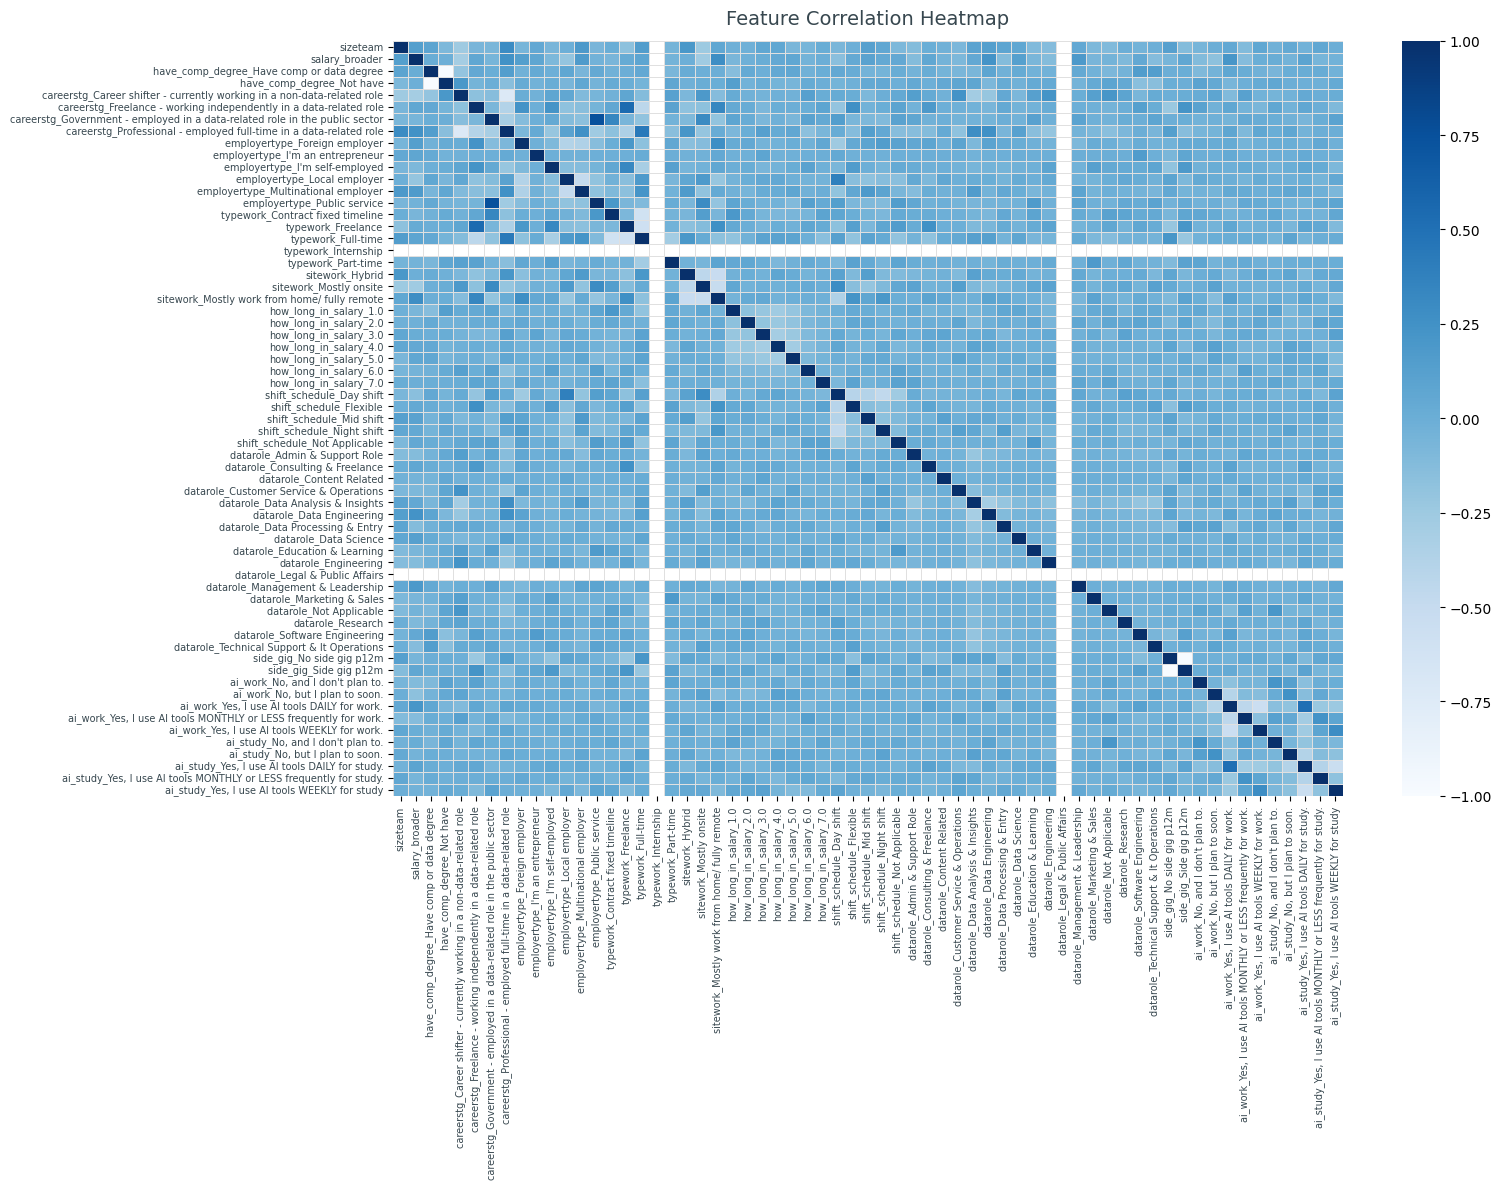

In [23]:
# We now see if we can weed out some more correlated features
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = X.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    ax         = ax,
    cmap       = 'Blues',
    annot      = False,   # too many columns for annotations
    linewidths = 0.5,
    linecolor  = '#E0E0E0',
    vmin       = -1,
    vmax       = 1,
    center     = 0,
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, color='#37474F', pad=12)
ax.tick_params(axis='x', labelsize=7, labelcolor='#37474F', rotation=90)
ax.tick_params(axis='y', labelsize=7, labelcolor='#37474F', rotation=0)

plt.tight_layout()
fig.savefig('assets/heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()


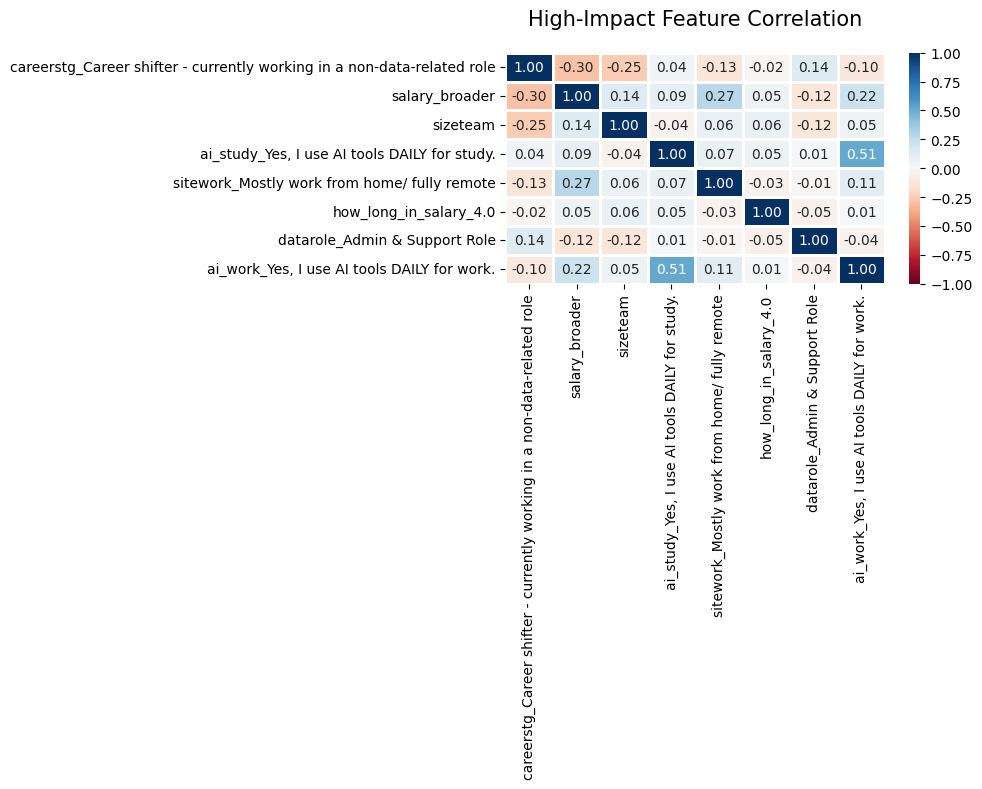

In [24]:
# 1. Define  top drivers from the SHAP table
top_drivers = [
    'careerstg_Career shifter - currently working in a non-data-related role',
    'salary_broader',
    'sizeteam',
    'ai_study_Yes, I use AI tools DAILY for study.',
    'sitework_Mostly work from home/ fully remote',
    'how_long_in_salary_4.0',
    'datarole_Admin & Support Role',
    'ai_work_Yes, I use AI tools DAILY for work.'
]

# 2. Create a subset correlation matrix
small_corr = X[top_drivers].corr()
corr_df = X[top_drivers].corr().round(2)
corr_df.to_csv('shap_bin/feature_correlations.csv', index=True)

# 3. Plot the refined heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    small_corr, 
    annot=True,          # Now possible since we have fewer columns
    fmt=".2f", 
    cmap='RdBu',       # Red/Blue is better for spotting negative vs positive corr
    center=0,
    vmin=-1, vmax=1,
    linewidths=1,
    linecolor='white'
)

plt.title('High-Impact Feature Correlation', fontsize=15, pad=20)
plt.tight_layout()
plt.savefig('assets/heatmap_small.png', dpi=150)
plt.show()

### What the Heatmap Shows

The correlation heat map does not show strong correlations anywhere, so the features are likely individual drivers of satisfaction.



### Usage of ai at work vs. satisfaction findings (from crosstabs using low-mid-high satisfaction groups as headers)
- Investigating since it is high in LR SHAP but low in RF SHAP
- Clearly a 20pt increase from Low Sat to High Sat, hence the LR detection.  RF is less sensitive to linear trends.
- Speculation:  AI use at work and satisfaction could imply many things.  Less social cost to asking questions, more empowerment, higher deep work "flow state" due to AI assistance, or workplace culture that values AI use instead of a legacy-thinking environment.

| Response | Total | Low Sat (1-4) | Sig. | Mid Sat (5-7) | Sig. | High Sat (8-10) | Sig. |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| | Total | a | | b | | c | |
| **Base (n)** | n=1675 | n=173 | | n=349 | | n=246 | |
| **Yes, I use AI tools DAILY for work.** | 55.9% | 47.4% | | 59.0% | a | 67.1% | ab |
| **Yes, I use AI tools WEEKLY for work.** | 18.5% | 17.9% | | 15.8% | | 18.3% | |
| **Yes, I use AI tools MONTHLY or LESS...** | 10.0% | 18.5% | bc | 11.5% | c | 7.3% | |
| **No, but I plan to soon.** | 14.2% | 12.1% | c | 11.2% | c | 6.5% | |
| **No, and I don't plan to.** | 1.4% | 4.0% | c | 2.6% | | 0.8% | |



# Investigating sitework due to a high LR SHAP but not RF SHAP, LGBM SHAP and lasso SHAP
- Mostly work from home/ fully remote shows significantly higher satisfaction than Mostly onsite.  
- Fully remote work is another key driver of satisfaction.

| Response | Total | Satisfaction Grp | | | | | |
|:---|:---|:---|:---|:---|:---|:---|:---|
| | Total | Low Sat (1-4) | Sig. | Mid Sat (5-7) | Sig. | High Sat (8-10) | Sig. |
| | | a | | b | | c | |
| Base (n) | n=773 | n=179 | | n=345 | | n=249 | |
| Mostly onsite | 37.8% | 51.4% | bc | 40.6% | c | 24.1% | |
| Hybrid | 29.5% | 27.9% | | 29.9% | | 30.1% | |
| Mostly work from home/ fully remote | 32.7% | 20.7% | | 29.6% | a | 45.8% | ab |




# Appendix

### ElasticNet solves a multicollinearity problem that this dataset does not have. The correlation heatmap confirmed the top drivers are independent signals — which means Lasso was already stable. ElasticNet would have confirmed that finding, not changed it.

In [ ]:
# ElasticNet Regression
# Hybrid of Lasso (L1) and Ridge (L2)
# Handles correlated features better than pure Lasso
# Requires scaling — same StandardScaler already used for LR and Lasso
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
import datetime

# Standardize — reuse X_scaled already computed for LR and Lasso
# If running this cell standalone, uncomment the two lines below:
# scaler_en = StandardScaler()
# X_scaled  = scaler_en.fit_transform(X)

elasticnet_tool = ElasticNet(
    alpha=0.1,       # same penalty strength as Lasso for comparability
    l1_ratio=0.5,    # 0.5 = equal L1 and L2 — balanced hybrid
    random_state=42,
    max_iter=10000   # increase from default 1000 to ensure convergence
)
elasticnet_tool.fit(X_scaled, y)

elasticnet_impact = pd.DataFrame({
    'Driver':   X.columns,
    'Score':    elasticnet_tool.coef_
})
elasticnet_impact['AbsScore'] = elasticnet_impact['Score'].abs()
elasticnet_impact = elasticnet_impact.sort_values(by='AbsScore', ascending=False)
elasticnet_impact.to_csv('impact/elasticnet_impact.csv', index=False)

# Save model
joblib.dump(elasticnet_tool, 'models/model_elasticnet.pkl')

# Load model
# elasticnet_tool = joblib.load('models/model_elasticnet.pkl')

print(elasticnet_impact.sort_values(by='AbsScore', ascending=False))
print("ElasticNet Regression done. Model saved. Date and Time: ",
      datetime.datetime.now().strftime("%Y/%m/%d %H:%M:%S"))